# Project 2: Traffic Prediction
----------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

# What are we doing in this notebook?
* First, just run all and appreciate the starter code I gave you. It's a next hour traffic prediction model! Your job will be to take it to the next level.
* Go get at LEAST one full year of data for CT or any other State you like (or want to visit... like Tennessee or California... have fun with this)
* Prep and download a full year of data. **I gave you Jan 2024 as a starter example.**
  * https://www.fhwa.dot.gov/policyinformation/tables/tmasdata/#y24
* Look at the awesome GCN I gave you with a 'feature vector' for the last 3 hours of traffic. We are baking in some time series info here. A good first approach.
* Try to get a better model... and then try to use your model autoregressively! The first pred is passed to the next hour and then the next hour etc.
* Compare your GCN to a ML or DL baseline - like linear regression or a decision tree or a simple neural net. Just remember you have 32 outputs and that persistence is a real problem!
* Feeling brave? Optional but will help you get a job. Add weather data to the feature vector.
  * https://mesonet.agron.iastate.edu/request/download.phtml?network=CT_ASOS
  * This is my favorite weather data site but be careful... data is messy and you need to consider how to harmonize airport vs. traffic nodes...

# GPU!
Go change to a high-RAM runtime and enable the GPU.

In [14]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Data Prep/Graph Construction
Raw data from here!
* https://www.fhwa.dot.gov/policyinformation/tables/tmasdata/#y24

I grabbed Jan 2024 for CT. It's a random tab-delimited file.

In [16]:
!pip install torch_geometric

In [17]:
import os
import pandas as pd
import numpy as np
import torch
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
from torch_geometric.utils import add_self_loops, coalesce

# ==========================================
# 0. CONFIG & PATHS
# ==========================================
# Modified to handle both .STA and .txt for station data, and find files in /content/
STA_PATH_BASENAME = 'CT_2024 (TMAS).STA'
VOL_PATH_BASENAME = 'CT_JAN_2024 (TMAS).VOL'

# Try to find STA_PATH, prioritizing the .STA extension if it exists,
# then trying the .txt extension, and finally a specific .txt file mentioned.
STA_PATH_OPTIONS = [
    STA_PATH_BASENAME,
    STA_PATH_BASENAME.replace('.STA', '.txt'), # If user provides a general .STA but we only have .txt
    'Station_Data_Extract_Pipe_Delimited_CleanData_2019.txt' # Specific .txt file mentioned by user
]

STA_PATH = None
for option in STA_PATH_OPTIONS:
    if os.path.exists(option):
        STA_PATH = option
        break
    elif os.path.exists(os.path.join('/content/', option)): # Check in /content/
        STA_PATH = os.path.join('/content/', option)
        break

if STA_PATH is None:
    raise FileNotFoundError(f"No suitable station data file found from options: {STA_PATH_OPTIONS}")
else:
    print(f"Using station data file: {STA_PATH}")

# Try to find VOL_PATH
VOL_PATH = None
if os.path.exists(VOL_PATH_BASENAME):
    VOL_PATH = VOL_PATH_BASENAME
elif os.path.exists(os.path.join('/content/', VOL_PATH_BASENAME)): # Check in /content/
    VOL_PATH = os.path.join('/content/', VOL_PATH_BASENAME)

if VOL_PATH is None:
    raise FileNotFoundError(f"Volume data file not found: {VOL_PATH_BASENAME}")
else:
    print(f"Using volume data file: {VOL_PATH}")

K_NEIGHBORS = 4

# ==========================================
# 1. TEMPORAL DATA PROCESSING
# ==========================================
print("Loading Volume Data...")
df_vol = pd.read_csv(VOL_PATH, dtype={'station_id': str}, sep='|')
df_vol.columns = [c.lower().strip() for c in df_vol.columns]

hour_cols = [f'hour_{str(i).zfill(2)}' for i in range(24)]

missing_hour_cols = [c for c in hour_cols if c not in df_vol.columns]
if missing_hour_cols:
    raise ValueError(f"Missing expected hour columns: {missing_hour_cols}")

daily_station = (
    df_vol
    .groupby(['station_id', 'year_record', 'month_record', 'day_record'], as_index=False)[hour_cols]
    .sum()
)

melted = pd.melt(
    daily_station,
    id_vars=['station_id', 'year_record', 'month_record', 'day_record'],
    value_vars=hour_cols,
    var_name='hour_str',
    value_name='volume'
)

melted['hour'] = melted['hour_str'].str.extract(r'(\d+)').astype(int)

date_cols = melted[['year_record', 'month_record', 'day_record', 'hour']].rename(
    columns={
        'year_record': 'year',
        'month_record': 'month',
        'day_record': 'day'
    }
)

melted['datetime'] = pd.to_datetime(date_cols, errors='coerce')
melted = melted.dropna(subset=['datetime'])

tensor_df = (
    melted
    .pivot(index='station_id', columns='datetime', values='volume')
    .sort_index(axis=1)
    .interpolate(axis=1)
    .fillna(0)
)

if tensor_df.shape[0] == 0:
    raise ValueError("No stations found in volume data after pivoting.")

print(f"Volume tensor table shape: {tensor_df.shape}")

# ==========================================
# 2. SPATIAL DATA PROCESSING & ALIGNMENT
# ==========================================
print("Loading Station Data & Aligning...")
df_sta = pd.read_csv(STA_PATH, dtype={'station_id': str}, sep='|')
df_sta.columns = [c.lower().strip() for c in df_sta.columns]

required_sta_cols = ['station_id', 'latitude', 'longitude']
missing_sta_cols = [c for c in required_sta_cols if c not in df_sta.columns]
if missing_sta_cols:
    raise ValueError(f"Missing expected station columns: {missing_sta_cols}")

df_sta = (
    df_sta
    .dropna(subset=['latitude', 'longitude'])
    .drop_duplicates(subset=['station_id'])
    .copy()
)

def fix_coord(val):
    val = float(val)
    return val / 1_000_000 if abs(val) > 1000 else val

df_sta['lat'] = df_sta['latitude'].apply(fix_coord)
df_sta['lon'] = df_sta['longitude'].apply(lambda x: -abs(fix_coord(x)))

# Keep only stations that appear in both files, preserving STA order
common_station_ids = [sid for sid in df_sta['station_id'] if sid in tensor_df.index]

if len(common_station_ids) == 0:
    raise ValueError("No overlapping station_id values found between STA and VOL files.")

aligned_sta = df_sta[df_sta['station_id'].isin(common_station_ids)].copy()
aligned_sta = aligned_sta.drop_duplicates(subset=['station_id']).reset_index(drop=True)

# Reindex tensor_df to match aligned station order
tensor_df_aligned = tensor_df.loc[aligned_sta['station_id']]

X_np = tensor_df_aligned.to_numpy(dtype=np.float32)
X_tensor = torch.tensor(X_np, dtype=torch.float)

lats = aligned_sta['lat'].to_list()
lons = aligned_sta['lon'].to_list()
station_ids = aligned_sta['station_id'].to_list()

print(f"Aligned stations: {len(station_ids)}")
print(f"X_tensor shape: {X_tensor.shape}")

# ==========================================
# 3. ROBUST KNN GRAPH CONSTRUCTION
# ==========================================
print("Building connected spatial manifold...")

coords = np.column_stack([lons, lats])
num_nodes = len(coords)

if num_nodes == 0:
    raise ValueError("No valid spatial coordinates available after alignment.")

edges = []

if num_nodes > 1:
    tree = KDTree(coords)
    actual_k = max(0, min(K_NEIGHBORS, num_nodes - 1))

    for i in range(num_nodes):
        dist, indices = tree.query(coords[i], k=actual_k + 1)

        # Ensure array-like output even when scipy returns a scalar
        indices = np.atleast_1d(indices)

        for neighbor_idx in indices:
            neighbor_idx = int(neighbor_idx)
            if i != neighbor_idx:
                edges.append([i, neighbor_idx])
                edges.append([neighbor_idx, i])

# Build edge_index safely as [2, E]
if len(edges) > 0:
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
else:
    edge_index = torch.zeros((2, 0), dtype=torch.long)

# IMPORTANT: coalesce returns edge_index directly here
edge_index = coalesce(edge_index, num_nodes=num_nodes)

# add_self_loops returns a tuple
edge_index, _ = add_self_loops(edge_index, num_nodes=num_nodes)

print(f"edge_index shape before/after self-loops: {edge_index.shape}")
print(f"SUCCESS: {X_tensor.shape[0]} Stations Aligned.")
print(f"Graph: {edge_index.shape[1]} Directed Edges (including self-loops).")

Using station data file: Station_Data_Extract_Pipe_Delimited_CleanData_2019.txt
Using volume data file: CT_JAN_2024 (TMAS).VOL
Loading Volume Data...
Volume tensor table shape: (32, 744)
Loading Station Data & Aligning...
Aligned stations: 18
X_tensor shape: torch.Size([18, 744])
Building connected spatial manifold...
edge_index shape before/after self-loops: torch.Size([2, 118])
SUCCESS: 18 Stations Aligned.
Graph: 118 Directed Edges (including self-loops).


/tmp/ipykernel_9028/357007550.py:109: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sta = pd.read_csv(STA_PATH, dtype={'station_id': str}, sep='|')


# State Map

Generating Basemap and Manifold...


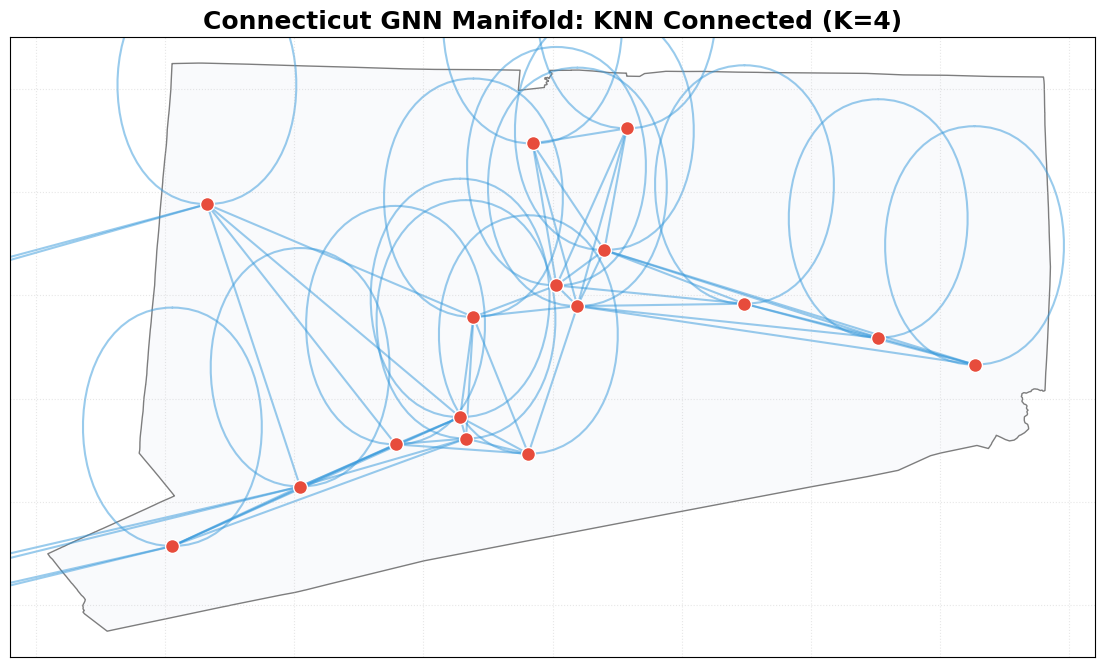

In [18]:
import geopandas as gpd
import networkx as nx

print("Generating Basemap and Manifold...")
url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
ct = gpd.read_file(url)
ct = ct[ct['STUSPS'] == 'CT'].to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(14, 10))
ct.plot(ax=ax, color='#f5f6fa', edgecolor='black', alpha=0.5)

# NetworkX Setup
pos = {i: (lons[i], lats[i]) for i in range(len(lons))}
G = nx.Graph()
G.add_nodes_from(pos.keys())
G.add_edges_from(edge_index.t().numpy().tolist())

# Draw the "Lines" (Edges)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#3498db', alpha=0.5, width=1.5)

# Draw the "Dots" (Nodes)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=100, node_color='#e74c3c', edgecolors='white')

# Zoom to CT
ax.set_xlim(-73.8, -71.7)
ax.set_ylim(40.9, 42.1)
ax.set_aspect('equal')

plt.title(f"Connecticut GNN Manifold: KNN Connected (K={K_NEIGHBORS})", fontsize=18, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.3)
plt.show()

# Time Series Viz

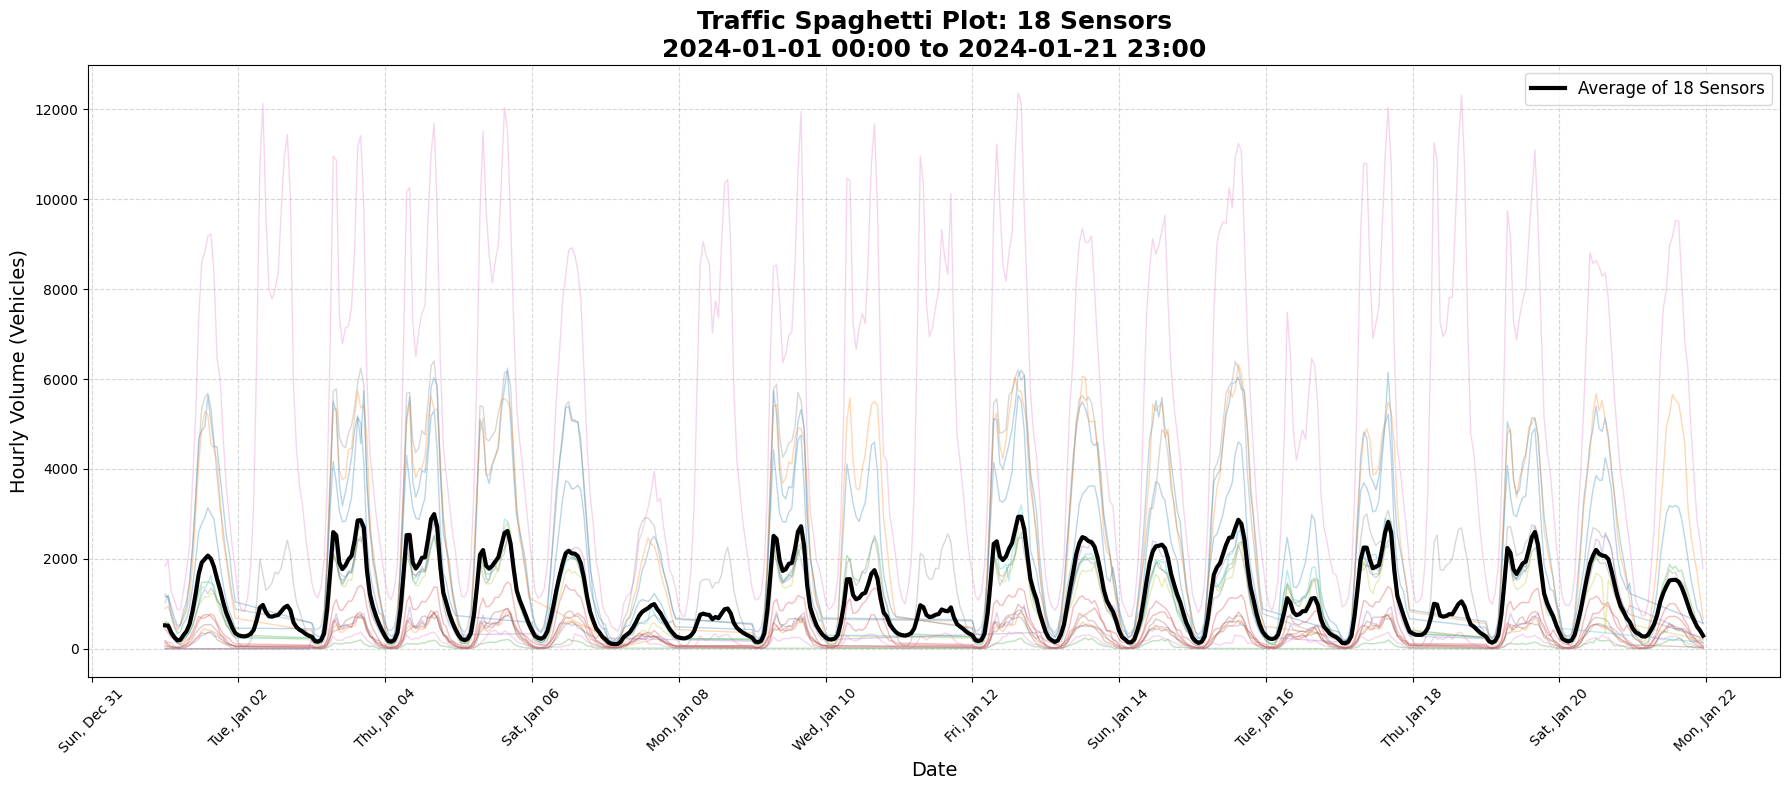

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# PREP: build plotting objects from prior traffic pipeline
# Assumes these already exist from your earlier cell:
#   - tensor_df_aligned   (rows = stations, cols = datetimes)
#   - X_tensor            (torch tensor version of the same data)
# =========================================================

# If you want to plot from the torch tensor:
x_real_aligned = X_tensor.detach().cpu().numpy()

# Datetime index from the aligned dataframe columns
t_index = pd.to_datetime(tensor_df_aligned.columns)

# Optional: sanity checks
if x_real_aligned.ndim != 2:
    raise ValueError(f"x_real_aligned must be 2D, got shape {x_real_aligned.shape}")

if len(t_index) != x_real_aligned.shape[1]:
    raise ValueError(
        f"Mismatch: len(t_index)={len(t_index)} but x_real_aligned has {x_real_aligned.shape[1]} time steps"
    )

# =========================================================
# SETTINGS
# =========================================================
num_sensors_to_plot = min(32, x_real_aligned.shape[0])
hours_to_plot = min(24 * 21, x_real_aligned.shape[1])  # up to 3 weeks, or less if not available

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(18, 8))

# Plot the spaghetti lines
for i in range(num_sensors_to_plot):
    plt.plot(
        t_index[:hours_to_plot],
        x_real_aligned[i, :hours_to_plot],
        linewidth=1,
        alpha=0.3
    )

# Plot the system average
system_average = x_real_aligned[:num_sensors_to_plot, :hours_to_plot].mean(axis=0)
plt.plot(
    t_index[:hours_to_plot],
    system_average,
    color='black',
    linewidth=3,
    label=f'Average of {num_sensors_to_plot} Sensors'
)

# =========================================================
# FORMATTING
# =========================================================
start_dt = pd.to_datetime(t_index[0]).strftime("%Y-%m-%d %H:%M")
end_dt = pd.to_datetime(t_index[hours_to_plot - 1]).strftime("%Y-%m-%d %H:%M")

plt.title(
    f"Traffic Spaghetti Plot: {num_sensors_to_plot} Sensors\n{start_dt} to {end_dt}",
    fontsize=18,
    fontweight='bold'
)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Hourly Volume (Vehicles)", fontsize=14)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a, %b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

# A Basic GCN

Here's our setup.

* each node = one traffic sensor
* each edge = a KNN spatial connection between nearby sensors
* each node’s input features = the last 3 hours of traffic for that sensor
* the model passes information across the graph twice
  * GCN layer 1: each node mixes its own 3-hour history with information from neighboring sensors. Then...
  * GCN layer 2: each node mixes again, now using neighbor-aware hidden features
* then outputs one number per node: the predicted traffic volume for the next hour (we have 32 sensors... so 32 next hour predictions. Your numbers different if you use a different State!)

In [20]:
!pip install torch_geometric

# Setting up our model

In [21]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv

# =========================================================
# 0. DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# 1. MODEL
# Input now uses a rolling lag window:
# x_t shape = [num_nodes, WINDOW_HOURS]
# target     = next hour, shape [num_nodes, 1]
# Keep class name the same so notebook Run All works cleanly
# =========================================================
class TrafficGCN(nn.Module):
    def __init__(self, node_features=3, hidden_dim=32, output_dim=1):
        super().__init__()
        self.conv1 = GCNConv(node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.relu(h)

        h = self.conv2(h, edge_index)
        h = F.relu(h)

        out = self.out(h)
        return out

# =========================================================
# 2. SETTINGS
# =========================================================
TEST_DAYS = 5
VAL_DAYS = 3
HOURS_PER_DAY = 24

TEST_HOURS = TEST_DAYS * HOURS_PER_DAY
VAL_HOURS = VAL_DAYS * HOURS_PER_DAY

WINDOW_HOURS = 3     # <-- last 3 hours become node features

HIDDEN_DIM = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
PATIENCE = 15

# =========================================================
# 3. PREP DATA
# Expected:
#   X_tensor shape = [num_nodes, num_time_steps]
# Build samples like:
#   x_t = X[:, t-3:t]   -> [num_nodes, 3]
#   y_t = X[:, t]       -> [num_nodes, 1]
# so we predict the next hour from the previous 3 hours
# =========================================================
X_all = X_tensor.clone().detach().float()

num_nodes, num_time_steps = X_all.shape
print("Raw tensor shape:", X_all.shape)

min_required = WINDOW_HOURS + TEST_HOURS + VAL_HOURS + 10
if num_time_steps < min_required:
    raise ValueError(
        f"Not enough time steps ({num_time_steps}) for WINDOW_HOURS={WINDOW_HOURS}, "
        f"TEST_HOURS={TEST_HOURS}, and VAL_HOURS={VAL_HOURS}."
    )

# ---------------------------------------------------------
# Sample indexing
# If time steps are 0...(T-1), valid targets are t = WINDOW_HOURS...(T-1)
# Number of samples = T - WINDOW_HOURS
# ---------------------------------------------------------
num_samples = num_time_steps - WINDOW_HOURS

test_start = num_samples - TEST_HOURS
val_start = test_start - VAL_HOURS
train_end = val_start

if train_end <= 0:
    raise ValueError("Training set would be empty. Reduce TEST_DAYS/VAL_DAYS or WINDOW_HOURS.")

# ---------------------------------------------------------
# Normalize using training portion only
# Need enough raw hours to support the training windows
# training samples use targets up to raw time index: WINDOW_HOURS + train_end - 1
# ---------------------------------------------------------
train_raw_end = WINDOW_HOURS + train_end
train_raw = X_all[:, :train_raw_end]

mean_per_node = train_raw.mean(dim=1, keepdim=True)
std_per_node = train_raw.std(dim=1, keepdim=True)
std_per_node = torch.where(std_per_node < 1e-6, torch.ones_like(std_per_node), std_per_node)

X_scaled = (X_all - mean_per_node) / std_per_node

print(f"Num nodes: {num_nodes}")
print(f"Num time steps: {num_time_steps}")
print(f"Window hours: {WINDOW_HOURS}")
print(f"Num supervised samples: {num_samples}")
print(f"Train samples: 0 to {train_end - 1}")
print(f"Val samples:   {val_start} to {test_start - 1}")
print(f"Test samples:  {test_start} to {num_samples - 1}")

# =========================================================
# 4. BUILD SAMPLE LISTS
# For sample s:
#   raw target time t = s + WINDOW_HOURS
#   input window = X[:, t-WINDOW_HOURS:t]
#   target       = X[:, t]
# =========================================================
samples = []
for s in range(num_samples):
    t = s + WINDOW_HOURS

    x_t = X_scaled[:, t - WINDOW_HOURS:t]      # [num_nodes, WINDOW_HOURS]
    y_t = X_scaled[:, t].unsqueeze(1)          # [num_nodes, 1]

    samples.append((x_t, y_t))

train_samples = samples[:train_end]
val_samples = samples[val_start:test_start]
test_samples = samples[test_start:]

print(f"Built {len(train_samples)} training samples")
print(f"Built {len(val_samples)} validation samples")
print(f"Built {len(test_samples)} test samples")

# =========================================================
# 5. MODEL SETUP
# =========================================================
model = TrafficGCN(
    node_features=WINDOW_HOURS,
    hidden_dim=HIDDEN_DIM,
    output_dim=1
).to(device)

edge_index = edge_index.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

Using device: cuda
Raw tensor shape: torch.Size([18, 744])
Num nodes: 18
Num time steps: 744
Window hours: 3
Num supervised samples: 741
Train samples: 0 to 548
Val samples:   549 to 620
Test samples:  621 to 740
Built 549 training samples
Built 72 validation samples
Built 120 test samples


## What does it look like?

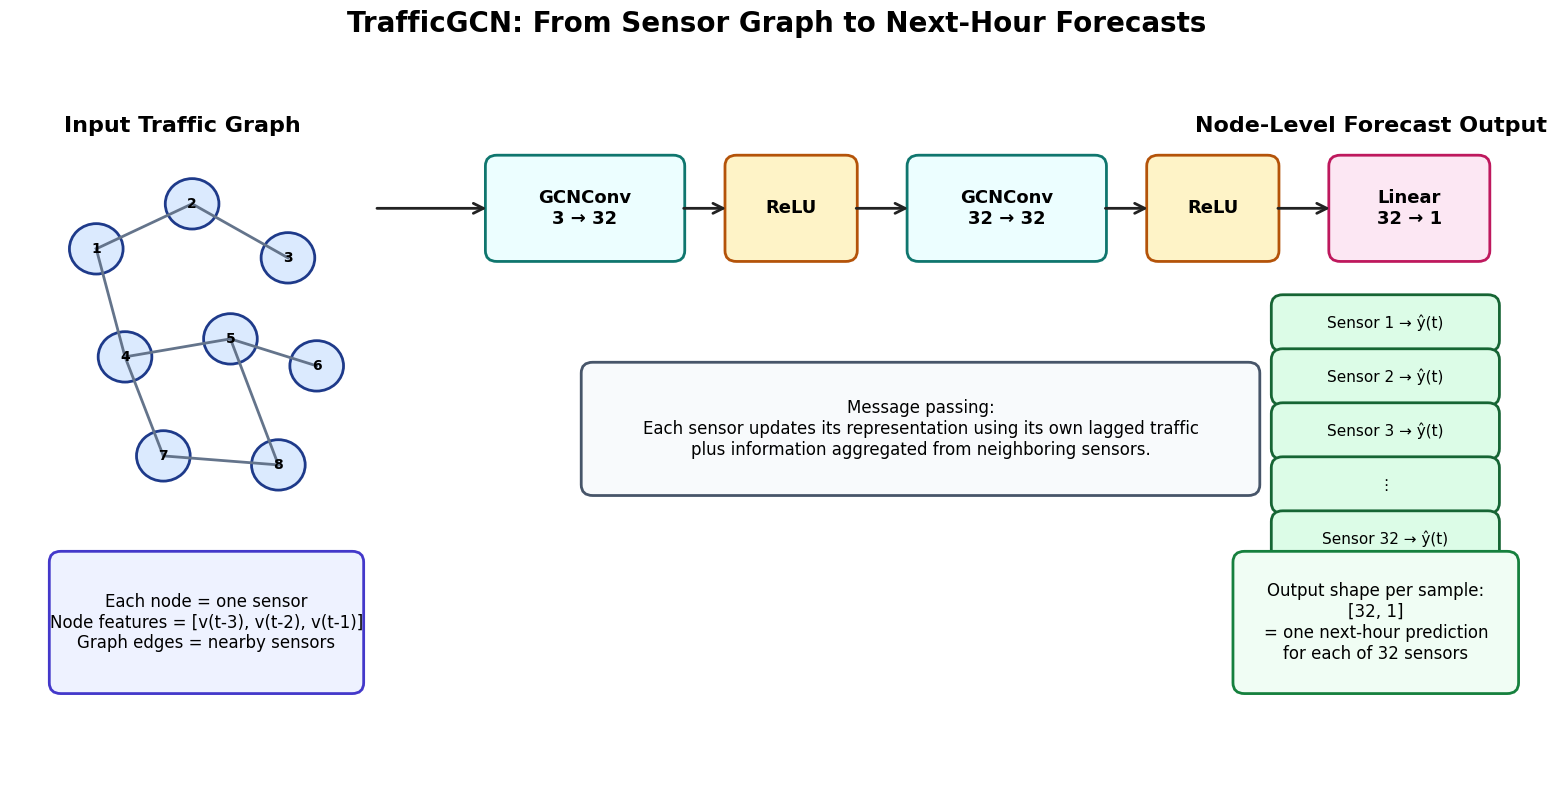

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 8)
ax.axis("off")

def rounded_box(x, y, w, h, text, fc="#f7f7f7", ec="#222222", fontsize=12, weight="normal"):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        linewidth=2, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, fontweight=weight)

def arrow(x1, y1, x2, y2, lw=2):
    arr = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->", mutation_scale=18,
        linewidth=lw, color="#222222"
    )
    ax.add_patch(arr)

def sensor_node(x, y, label, fc="#dbeafe"):
    circ = Circle((x, y), 0.28, facecolor=fc, edgecolor="#1e3a8a", linewidth=2)
    ax.add_patch(circ)
    ax.text(x, y, label, ha="center", va="center", fontsize=10, fontweight="bold")

# ---------------------------------------------------------
# Left: graph snapshot with sensors
# ---------------------------------------------------------
ax.text(1.8, 7.2, "Input Traffic Graph", fontsize=16, fontweight="bold", ha="center")

sensor_positions = [
    (0.9, 5.9, "1"),
    (1.9, 6.4, "2"),
    (2.9, 5.8, "3"),
    (1.2, 4.7, "4"),
    (2.3, 4.9, "5"),
    (3.2, 4.6, "6"),
    (1.6, 3.6, "7"),
    (2.8, 3.5, "8"),
]
for x, y, lab in sensor_positions:
    sensor_node(x, y, lab)

edges_demo = [
    ((0.9,5.9),(1.9,6.4)),
    ((1.9,6.4),(2.9,5.8)),
    ((0.9,5.9),(1.2,4.7)),
    ((1.2,4.7),(2.3,4.9)),
    ((2.3,4.9),(3.2,4.6)),
    ((1.2,4.7),(1.6,3.6)),
    ((2.3,4.9),(2.8,3.5)),
    ((1.6,3.6),(2.8,3.5)),
]
for (x1, y1), (x2, y2) in edges_demo:
    ax.plot([x1, x2], [y1, y2], color="#64748b", linewidth=2)

rounded_box(
    0.45, 1.0, 3.2, 1.5,
    "Each node = one sensor\nNode features = [v(t-3), v(t-2), v(t-1)]\nGraph edges = nearby sensors",
    fc="#eef2ff", ec="#4338ca", fontsize=12
)

# ---------------------------------------------------------
# Middle: model pipeline
# ---------------------------------------------------------
rounded_box(5.0, 5.8, 2.0, 1.1, "GCNConv\n3 → 32", fc="#ecfeff", ec="#0f766e", fontsize=13, weight="bold")
rounded_box(7.5, 5.8, 1.3, 1.1, "ReLU", fc="#fef3c7", ec="#b45309", fontsize=13, weight="bold")
rounded_box(9.4, 5.8, 2.0, 1.1, "GCNConv\n32 → 32", fc="#ecfeff", ec="#0f766e", fontsize=13, weight="bold")
rounded_box(11.9, 5.8, 1.3, 1.1, "ReLU", fc="#fef3c7", ec="#b45309", fontsize=13, weight="bold")
rounded_box(13.8, 5.8, 1.6, 1.1, "Linear\n32 → 1", fc="#fce7f3", ec="#be185d", fontsize=13, weight="bold")

arrow(3.8, 6.35, 5.0, 6.35)
arrow(7.0, 6.35, 7.5, 6.35)
arrow(8.8, 6.35, 9.4, 6.35)
arrow(11.4, 6.35, 11.9, 6.35)
arrow(13.2, 6.35, 13.8, 6.35)

rounded_box(
    6.0, 3.2, 7.0, 1.4,
    "Message passing:\nEach sensor updates its representation using its own lagged traffic\nplus information aggregated from neighboring sensors.",
    fc="#f8fafc", ec="#475569", fontsize=12
)

# ---------------------------------------------------------
# Right: output predictions
# ---------------------------------------------------------
ax.text(14.2, 7.2, "Node-Level Forecast Output", fontsize=16, fontweight="bold", ha="center")

output_y = [4.8, 4.2, 3.6, 3.0, 2.4]
labels = ["Sensor 1 → ŷ(t)", "Sensor 2 → ŷ(t)", "Sensor 3 → ŷ(t)", "⋮", "Sensor 32 → ŷ(t)"]
for yy, lab in zip(output_y, labels):
    rounded_box(13.2, yy, 2.3, 0.55, lab, fc="#dcfce7", ec="#166534", fontsize=11)

rounded_box(
    12.8, 1.0, 2.9, 1.5,
    "Output shape per sample:\n[32, 1]\n= one next-hour prediction\nfor each of 32 sensors",
    fc="#f0fdf4", ec="#15803d", fontsize=12
)

plt.title("TrafficGCN: From Sensor Graph to Next-Hour Forecasts", fontsize=20, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

ChatGPT made this for me - it's awesome! Note that the text corresponds to CT and you can update it for your State if you choose something else.

# Run the model!


Starting training...

Epoch 001 | Train Loss: 0.343522 | Val Loss: 0.308302
Epoch 002 | Train Loss: 0.218357 | Val Loss: 0.284153
Epoch 003 | Train Loss: 0.207747 | Val Loss: 0.268239
Epoch 004 | Train Loss: 0.201332 | Val Loss: 0.260264
Epoch 005 | Train Loss: 0.197742 | Val Loss: 0.256411
Epoch 006 | Train Loss: 0.195929 | Val Loss: 0.254740
Epoch 007 | Train Loss: 0.195196 | Val Loss: 0.253580
Epoch 008 | Train Loss: 0.191405 | Val Loss: 0.252154
Epoch 009 | Train Loss: 0.191016 | Val Loss: 0.251758
Epoch 010 | Train Loss: 0.188516 | Val Loss: 0.250987
Epoch 011 | Train Loss: 0.187493 | Val Loss: 0.250647
Epoch 012 | Train Loss: 0.186122 | Val Loss: 0.250248
Epoch 013 | Train Loss: 0.184897 | Val Loss: 0.249620
Epoch 014 | Train Loss: 0.183667 | Val Loss: 0.249852
Epoch 015 | Train Loss: 0.183149 | Val Loss: 0.249039
Epoch 016 | Train Loss: 0.182992 | Val Loss: 0.250354
Epoch 017 | Train Loss: 0.182487 | Val Loss: 0.249966
Epoch 018 | Train Loss: 0.182264 | Val Loss: 0.249821
Epoch

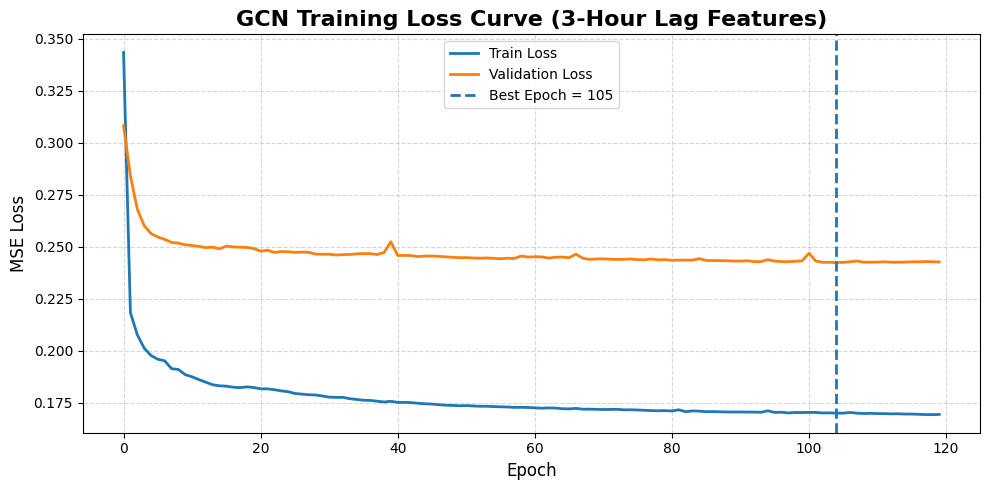

In [23]:


# =========================================================
# 6. TRAIN / EVAL FUNCTIONS
# =========================================================
def run_epoch(sample_list, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    for x_t, y_t in sample_list:
        x_t = x_t.to(device)
        y_t = y_t.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            pred = model(x_t, edge_index)
            loss = criterion(pred, y_t)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(sample_list), 1)

# =========================================================
# 7. TRAIN WITH EARLY STOPPING
# =========================================================
best_val_loss = np.inf
best_state = None
best_epoch = -1
epochs_no_improve = 0

train_losses = []
val_losses = []

print("\nStarting training...\n")

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_samples, training=True)
    val_loss = run_epoch(val_samples, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.6f}")

# =========================================================
# 8. FINAL TEST LOSS
# =========================================================
test_loss = run_epoch(test_samples, training=False)
print(f"Test loss: {test_loss:.6f}")

# =========================================================
# 9. PLOT LOSS CURVES
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

if best_epoch > 0:
    plt.axvline(best_epoch - 1, linestyle="--", linewidth=2, label=f"Best Epoch = {best_epoch}")

plt.title("GCN Training Loss Curve (3-Hour Lag Features)", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# How did our model do?

## Time series and metrics

Scaled prediction array shape: (18, 120)
Scaled actual array shape: (18, 120)
Unscaled prediction array shape: (18, 120)
Unscaled actual array shape: (18, 120)
Persistence shape: (18, 120)
Moving-average shape: (18, 120)
Baseline actuals shape: (18, 120)

===== TEST METRICS (ORIGINAL TRAFFIC UNITS) =====

GCN
  MSE :  1,100,246.625
  RMSE:  1,048.926
  MAE :  441.017

Persistence Baseline
  MSE :  153,570.812
  RMSE:  391.881
  MAE :  187.105

3-Hour Moving Average Baseline
  MSE :  424,295.312
  RMSE:  651.380
  MAE :  332.208


Worst sensors by RMSE:
    sensor_idx         rmse          mae
6            6  3464.091800  2344.409424
7            7  2149.569027  1665.334839
11          11  1128.334447   900.659180
10          10   938.349782   750.121338
17          17   505.754418   349.243622
0            0   447.991438   296.113251
14          14   421.976988   353.557159
2            2   341.249828   265.473572
8            8   339.917557   231.145782
9            9   268.190260   2

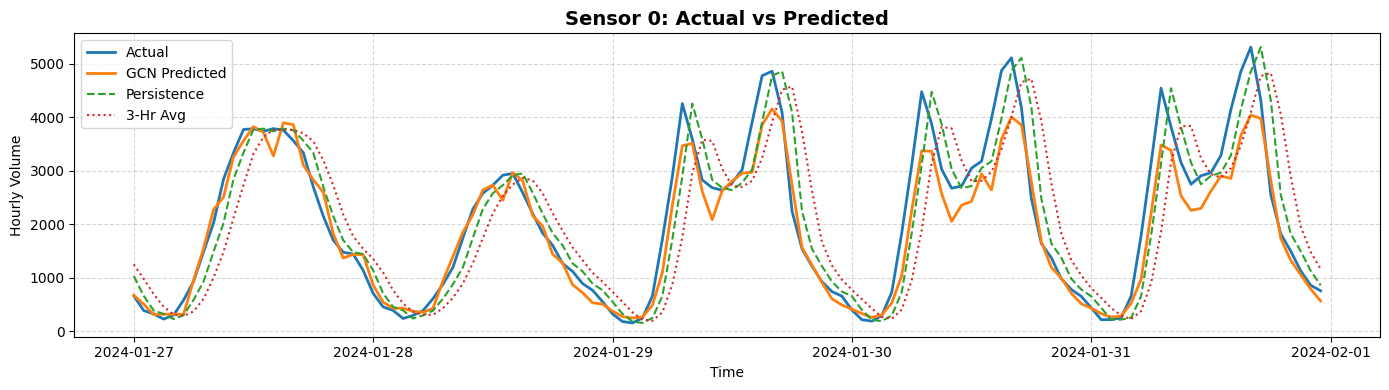

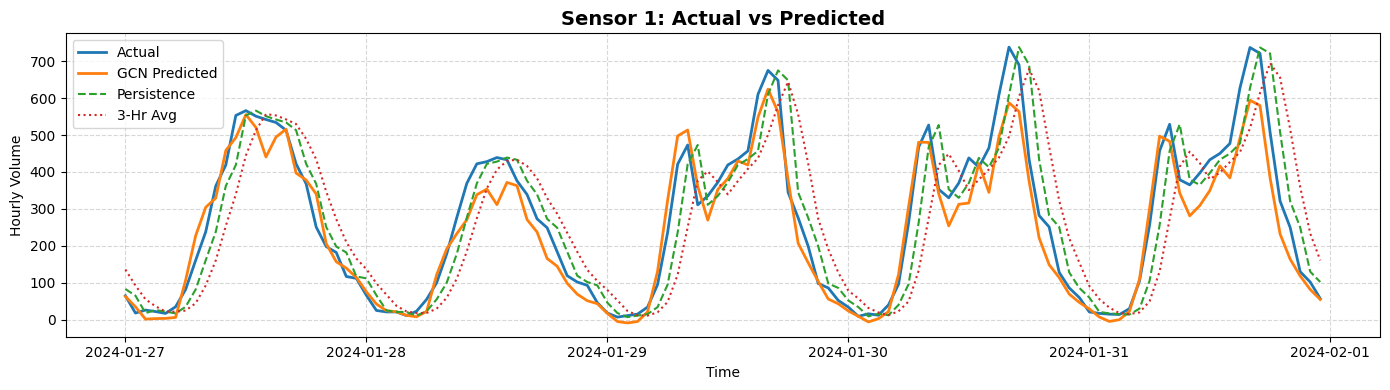

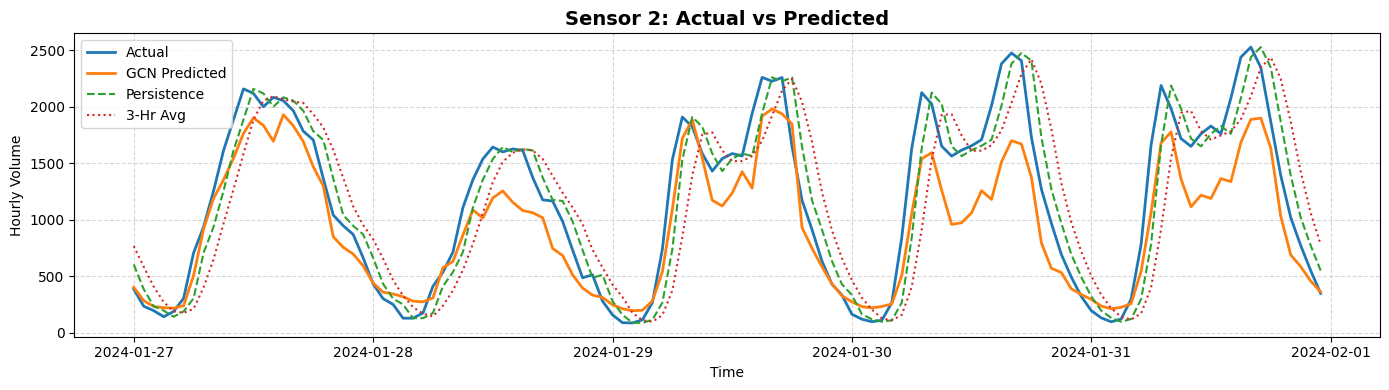

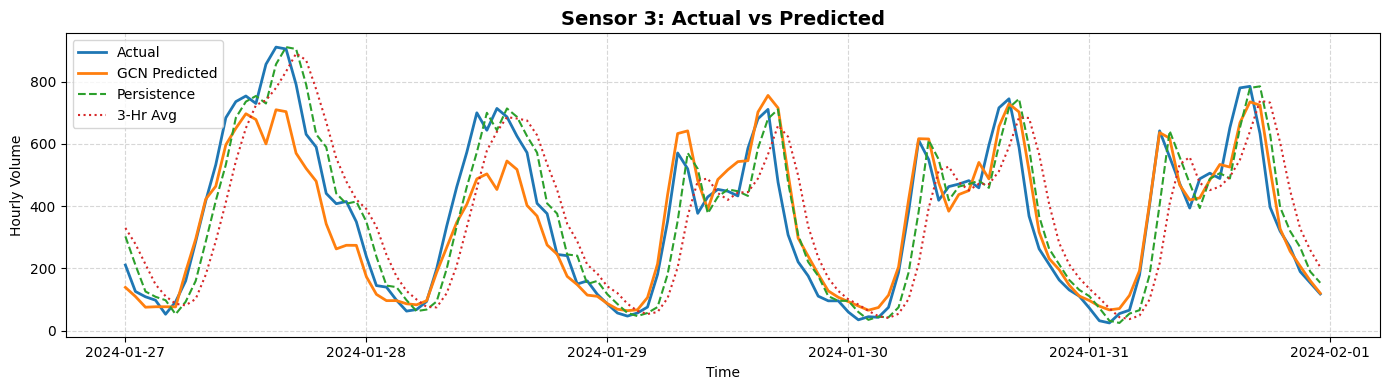

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================================================
# 1. COLLECT MODEL PREDICTIONS ON TEST SET
# =========================================================
model.eval()

all_preds_scaled = []
all_actuals_scaled = []

with torch.no_grad():
    for x_t, y_t in test_samples:
        x_t = x_t.to(device)
        pred = model(x_t, edge_index).detach().cpu()   # [num_nodes, 1]
        all_preds_scaled.append(pred.numpy())
        all_actuals_scaled.append(y_t.numpy())

# Shape: [num_test_samples, num_nodes, 1]
all_preds_scaled = np.array(all_preds_scaled)
all_actuals_scaled = np.array(all_actuals_scaled)

# Squeeze last dimension -> [num_test_samples, num_nodes]
all_preds_scaled = np.squeeze(all_preds_scaled, axis=2)
all_actuals_scaled = np.squeeze(all_actuals_scaled, axis=2)

# Transpose to [num_nodes, num_test_samples]
pred_scaled = all_preds_scaled.T
actual_scaled = all_actuals_scaled.T

print("Scaled prediction array shape:", pred_scaled.shape)
print("Scaled actual array shape:", actual_scaled.shape)

# =========================================================
# 2. UNSCALE BACK TO ORIGINAL TRAFFIC UNITS
# =========================================================
mean_np = mean_per_node.detach().cpu().numpy()   # [num_nodes, 1]
std_np = std_per_node.detach().cpu().numpy()     # [num_nodes, 1]

pred_unscaled = pred_scaled * std_np + mean_np
actual_unscaled = actual_scaled * std_np + mean_np

print("Unscaled prediction array shape:", pred_unscaled.shape)
print("Unscaled actual array shape:", actual_unscaled.shape)

# =========================================================
# 3. BUILD BASELINES ON TEST SET
#    Persistence: predict next hour = last observed hour
#    Moving avg:  predict next hour = mean of last WINDOW_HOURS
# =========================================================
persist_preds = []
ma_preds = []
baseline_actuals = []

for s in range(test_start, num_samples):
    t = s + WINDOW_HOURS

    hist_window = X_all[:, t - WINDOW_HOURS:t]     # [num_nodes, WINDOW_HOURS]
    y_true = X_all[:, t].detach().cpu().numpy()    # [num_nodes]

    y_persist = hist_window[:, -1].detach().cpu().numpy()
    y_ma = hist_window.mean(dim=1).detach().cpu().numpy()

    persist_preds.append(y_persist)
    ma_preds.append(y_ma)
    baseline_actuals.append(y_true)

# Convert to [num_nodes, num_test_samples]
persist_preds = np.array(persist_preds).T
ma_preds = np.array(ma_preds).T
baseline_actuals = np.array(baseline_actuals).T

# Sanity check
print("Persistence shape:", persist_preds.shape)
print("Moving-average shape:", ma_preds.shape)
print("Baseline actuals shape:", baseline_actuals.shape)

# =========================================================
# 4. METRICS
# =========================================================
def compute_metrics(y_true, y_pred, label="Model"):
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)

    print(f"{label}")
    print(f"  MSE :  {mse:,.3f}")
    print(f"  RMSE:  {rmse:,.3f}")
    print(f"  MAE :  {mae:,.3f}")
    print()

    return {"mse": mse, "rmse": rmse, "mae": mae}

print("\n===== TEST METRICS (ORIGINAL TRAFFIC UNITS) =====\n")
gcn_metrics = compute_metrics(actual_unscaled, pred_unscaled, label="GCN")
persist_metrics = compute_metrics(baseline_actuals, persist_preds, label="Persistence Baseline")
ma_metrics = compute_metrics(baseline_actuals, ma_preds, label=f"{WINDOW_HOURS}-Hour Moving Average Baseline")

# =========================================================
# 5. PER-SENSOR METRICS
# =========================================================
sensor_rows = []
for i in range(num_nodes):
    rmse_i = np.sqrt(mean_squared_error(actual_unscaled[i], pred_unscaled[i]))
    mae_i = mean_absolute_error(actual_unscaled[i], pred_unscaled[i])

    sensor_rows.append({
        "sensor_idx": i,
        "rmse": rmse_i,
        "mae": mae_i
    })

sensor_metrics_df = pd.DataFrame(sensor_rows).sort_values("rmse", ascending=False)
print("\nWorst sensors by RMSE:")
print(sensor_metrics_df.head(10))

# =========================================================
# 6. BUILD TEST TIME INDEX FOR PLOTTING
# =========================================================
if 'tensor_df_aligned' in globals():
    full_time_index = pd.to_datetime(tensor_df_aligned.columns)
    test_target_times = full_time_index[WINDOW_HOURS + test_start : WINDOW_HOURS + num_samples]
else:
    test_target_times = np.arange(actual_unscaled.shape[1])

# =========================================================
# 7. PLOT ACTUAL VS PREDICTED FOR A FEW SENSORS
# =========================================================
num_plot_sensors = min(4, num_nodes)
sensor_choices = list(range(num_plot_sensors))

for sensor_idx in sensor_choices:
    plt.figure(figsize=(14, 4))
    plt.plot(test_target_times, actual_unscaled[sensor_idx], linewidth=2, label="Actual")
    plt.plot(test_target_times, pred_unscaled[sensor_idx], linewidth=2, label="GCN Predicted")
    plt.plot(test_target_times, persist_preds[sensor_idx], linewidth=1.5, linestyle="--", label="Persistence")
    plt.plot(test_target_times, ma_preds[sensor_idx], linewidth=1.5, linestyle=":", label=f"{WINDOW_HOURS}-Hr Avg")

    plt.title(f"Sensor {sensor_idx}: Actual vs Predicted", fontsize=14, fontweight='bold')
    plt.xlabel("Time")
    plt.ylabel("Hourly Volume")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Scatterplots

Train GCN actual/pred: (18, 549) (18, 549)
Val   GCN actual/pred: (18, 72) (18, 72)
Test  GCN actual/pred: (18, 120) (18, 120)
Train baseline actual/persist/ma: (18, 549) (18, 549) (18, 549)
Val   baseline actual/persist/ma: (18, 72) (18, 72) (18, 72)
Test  baseline actual/persist/ma: (18, 120) (18, 120) (18, 120)


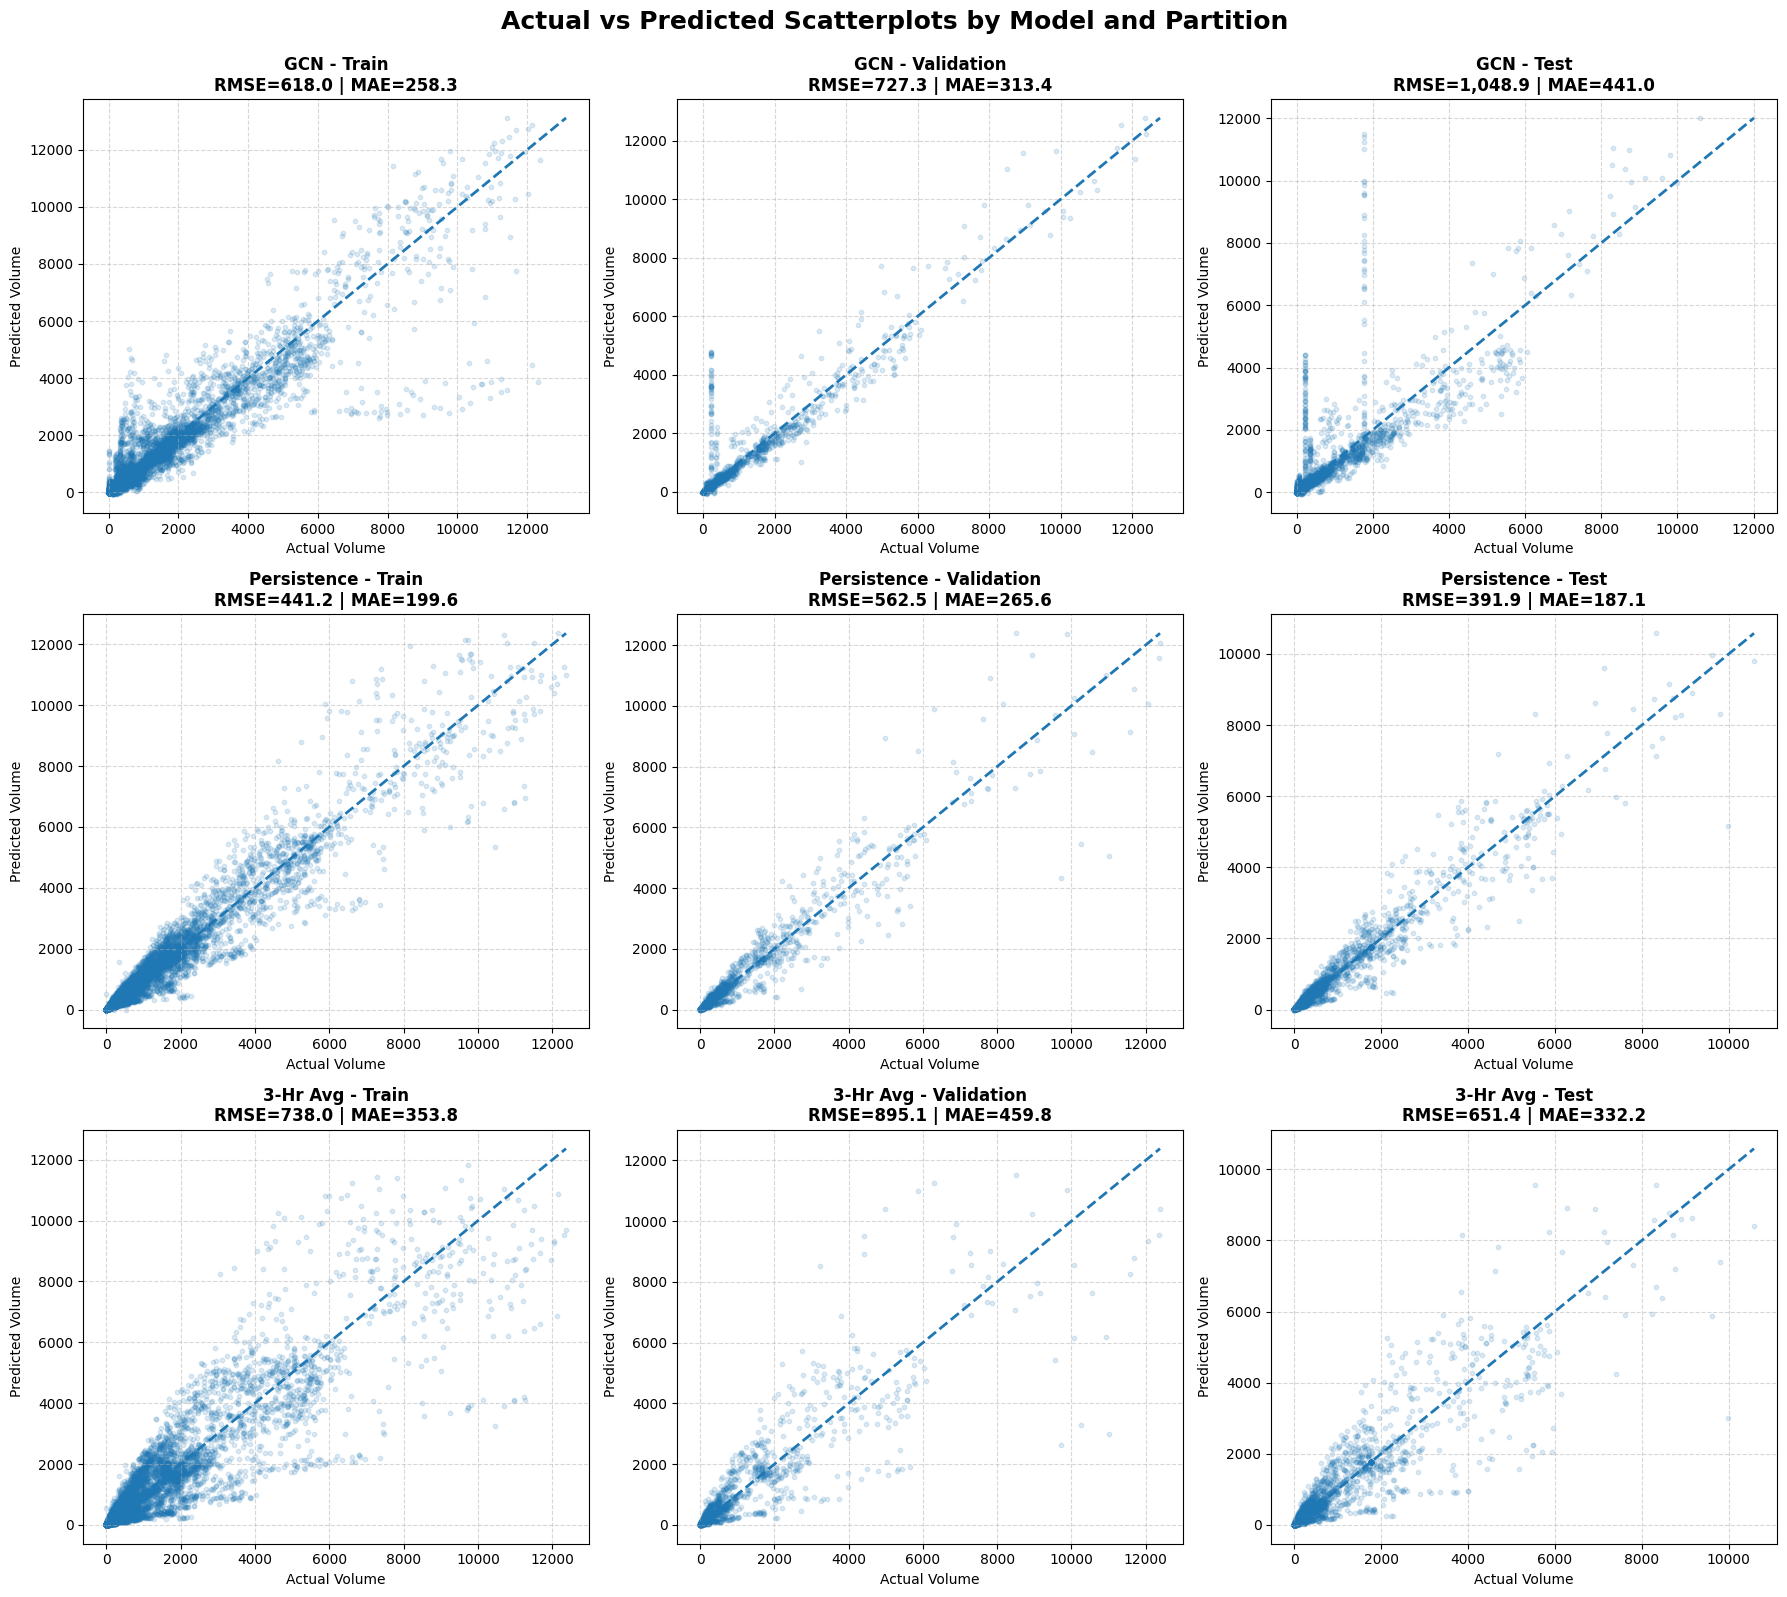

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================================================
# 1. HELPER: COLLECT PREDICTIONS FOR ANY PARTITION
# Returns unscaled arrays shaped [num_nodes, num_partition_samples]
# =========================================================
def collect_gcn_predictions(sample_list):
    model.eval()

    preds_scaled = []
    actuals_scaled = []

    with torch.no_grad():
        for x_t, y_t in sample_list:
            x_t = x_t.to(device)
            pred = model(x_t, edge_index).detach().cpu().numpy()   # [num_nodes, 1]
            preds_scaled.append(pred)
            actuals_scaled.append(y_t.numpy())                     # [num_nodes, 1]

    preds_scaled = np.squeeze(np.array(preds_scaled), axis=2).T    # [num_nodes, n_samples]
    actuals_scaled = np.squeeze(np.array(actuals_scaled), axis=2).T

    mean_np = mean_per_node.detach().cpu().numpy()   # [num_nodes, 1]
    std_np = std_per_node.detach().cpu().numpy()     # [num_nodes, 1]

    preds_unscaled = preds_scaled * std_np + mean_np
    actuals_unscaled = actuals_scaled * std_np + mean_np

    return actuals_unscaled, preds_unscaled

# =========================================================
# 2. HELPER: COLLECT BASELINE PREDICTIONS FOR A RANGE OF SAMPLE INDICES
# sample indices s correspond to supervised samples:
#   target raw time t = s + WINDOW_HOURS
# =========================================================
def collect_baselines(sample_start, sample_end):
    persist_preds = []
    ma_preds = []
    actuals = []

    for s in range(sample_start, sample_end):
        t = s + WINDOW_HOURS

        hist_window = X_all[:, t - WINDOW_HOURS:t]        # [num_nodes, WINDOW_HOURS]
        y_true = X_all[:, t].detach().cpu().numpy()       # [num_nodes]

        y_persist = hist_window[:, -1].detach().cpu().numpy()
        y_ma = hist_window.mean(dim=1).detach().cpu().numpy()

        persist_preds.append(y_persist)
        ma_preds.append(y_ma)
        actuals.append(y_true)

    persist_preds = np.array(persist_preds).T             # [num_nodes, n_samples]
    ma_preds = np.array(ma_preds).T
    actuals = np.array(actuals).T

    return actuals, persist_preds, ma_preds

# =========================================================
# 3. COLLECT PREDICTIONS FOR TRAIN / VAL / TEST
# =========================================================
# GCN
train_actual_gcn, train_pred_gcn = collect_gcn_predictions(train_samples)
val_actual_gcn, val_pred_gcn = collect_gcn_predictions(val_samples)
test_actual_gcn, test_pred_gcn = collect_gcn_predictions(test_samples)

# Baselines
train_actual_base, train_pred_persist, train_pred_ma = collect_baselines(0, train_end)
val_actual_base, val_pred_persist, val_pred_ma = collect_baselines(val_start, test_start)
test_actual_base, test_pred_persist, test_pred_ma = collect_baselines(test_start, num_samples)

# Sanity checks
print("Train GCN actual/pred:", train_actual_gcn.shape, train_pred_gcn.shape)
print("Val   GCN actual/pred:", val_actual_gcn.shape, val_pred_gcn.shape)
print("Test  GCN actual/pred:", test_actual_gcn.shape, test_pred_gcn.shape)

print("Train baseline actual/persist/ma:", train_actual_base.shape, train_pred_persist.shape, train_pred_ma.shape)
print("Val   baseline actual/persist/ma:", val_actual_base.shape, val_pred_persist.shape, val_pred_ma.shape)
print("Test  baseline actual/persist/ma:", test_actual_base.shape, test_pred_persist.shape, test_pred_ma.shape)

# =========================================================
# 4. METRIC HELPER
# =========================================================
def get_metrics(y_true, y_pred):
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    mse = mean_squared_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    return mse, rmse, mae

# =========================================================
# 5. SCATTERPLOT HELPER
# =========================================================
def scatter_panel(ax, y_true, y_pred, title):
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    mse, rmse, mae = get_metrics(y_true, y_pred)

    ax.scatter(y_true_flat, y_pred_flat, alpha=0.15, s=10)

    min_val = min(y_true_flat.min(), y_pred_flat.min())
    max_val = max(y_true_flat.max(), y_pred_flat.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2)

    ax.set_title(f"{title}\nRMSE={rmse:,.1f} | MAE={mae:,.1f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Actual Volume")
    ax.set_ylabel("Predicted Volume")
    ax.grid(True, linestyle="--", alpha=0.5)

# =========================================================
# 6. BUILD 3x3 GRID
# Rows   = Model
# Cols   = Train / Val / Test
# =========================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# -------- Row 1: GCN --------
scatter_panel(axes[0, 0], train_actual_gcn, train_pred_gcn, "GCN - Train")
scatter_panel(axes[0, 1], val_actual_gcn, val_pred_gcn, "GCN - Validation")
scatter_panel(axes[0, 2], test_actual_gcn, test_pred_gcn, "GCN - Test")

# -------- Row 2: Persistence --------
scatter_panel(axes[1, 0], train_actual_base, train_pred_persist, "Persistence - Train")
scatter_panel(axes[1, 1], val_actual_base, val_pred_persist, "Persistence - Validation")
scatter_panel(axes[1, 2], test_actual_base, test_pred_persist, "Persistence - Test")

# -------- Row 3: 3-Hour Average --------
scatter_panel(axes[2, 0], train_actual_base, train_pred_ma, f"{WINDOW_HOURS}-Hr Avg - Train")
scatter_panel(axes[2, 1], val_actual_base, val_pred_ma, f"{WINDOW_HOURS}-Hr Avg - Validation")
scatter_panel(axes[2, 2], test_actual_base, test_pred_ma, f"{WINDOW_HOURS}-Hr Avg - Test")

plt.suptitle("Actual vs Predicted Scatterplots by Model and Partition", fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Comments
* Well, it's REALLY hard to beat persistence.
* Your model does pretty good for only a few weeks of data.
* The data is a little dirty - see how some days drop out for some stations? Flat lines in the time series plot. You may want to try to fix that... you'll get a better result...
* Don't rush to say GCN is best thing ever. Compare your results to 'the window method' with a decision tree or some basic method. How does that baseline model compare to a GCN? You always need to convince the boss that the extra rigor is required.

#WHERE DENIS STARTS

In [27]:
# --- EDA on df_vol (Raw Volume Data) ---
print("\n--- EDA: Raw Volume Data (df_vol) ---")
print("Shape:", df_vol.shape)
print("\nInfo:")
df_vol.info()
print("\nDescriptive Statistics:")
print(df_vol.describe(include='all'))
print("\nMissing Values:")
print(df_vol.isnull().sum()[df_vol.isnull().sum() > 0])
print("\nUnique F_System values:", df_vol['f_system'].unique())


# --- EDA on df_sta (Raw Station Data) ---
print("\n\n--- EDA: Raw Station Data (df_sta) ---")
print("Shape:", df_sta.shape)
print("\nInfo:")
df_sta.info()
print("\nDescriptive Statistics:")
print(df_sta.describe(include='all'))
print("\nMissing Values:")
print(df_sta.isnull().sum()[df_sta.isnull().sum() > 0])
print("\nUnique record_type values:", df_sta['record_type'].unique())
print("\nUnique travel_dir values:", df_sta['travel_dir'].unique())
print("\nUnique travel_lane values:", df_sta['travel_lane'].unique())


# --- EDA on tensor_df_aligned (Processed Volume Data for Model) ---
print("\n\n--- EDA: Processed Volume Data (tensor_df_aligned) ---")
print("Shape:", tensor_df_aligned.shape)
print("\nDescriptive Statistics (first 5 time steps, all stations):")
print(tensor_df_aligned.iloc[:, :5].describe())
print("\nDescriptive Statistics (all time steps, first 5 stations):")
print(tensor_df_aligned.iloc[:5, :].T.describe()) # Transpose to get stats across time for each station
print("\nMissing Values (should be 0 after interpolation/fillna):")
print(tensor_df_aligned.isnull().sum().sum())


--- EDA: Raw Volume Data (df_vol) ---
Shape: (1989, 35)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 35 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   record_type   1989 non-null   object 
 1   state_code    1989 non-null   int64  
 2   f_system      1989 non-null   object 
 3   station_id    1989 non-null   object 
 4   travel_dir    1989 non-null   int64  
 5   travel_lane   1989 non-null   int64  
 6   year_record   1989 non-null   int64  
 7   month_record  1989 non-null   int64  
 8   day_record    1989 non-null   int64  
 9   day_of_week   1989 non-null   int64  
 10  hour_00       1989 non-null   int64  
 11  hour_01       1989 non-null   int64  
 12  hour_02       1989 non-null   int64  
 13  hour_03       1989 non-null   int64  
 14  hour_04       1989 non-null   int64  
 15  hour_05       1989 non-null   int64  
 16  hour_06       1989 non-null   int64  
 17  hour_07